mypy: disable-error-code="import-untyped,no-redef,misc"

In [1]:
"""Notebook source for comparing the retained Egglog baseline to archived paper artifacts."""

'Notebook source for comparing the retained Egglog baseline to archived paper artifacts.'

# 2026-03 - Replicating the Param-Eq Paper in Egglog

This notebook rebuilds the de Franca and Kronberger (2023) paper figures from
the archived Haskell experiment outputs and compares them to an Egglog
translation of the older `param-eq-haskell` simplification pipeline.

The Haskell sources this notebook is tracing back to are:
- `../param-eq-haskell/src/FixTree.hs`
- `../param-eq-haskell/src/Main.hs`

It is artifacts-first:
- it reads normalized Haskell artifacts from `python/egglog/exp/param_eq/artifacts`
- it reads the Egglog corpus results from the same directory
- it does not run Haskell at notebook execution time

Offline regeneration commands from the repository root:
- `uv run python -m egglog.exp.param_eq.normalize_archives`
- `uv run python -m egglog.exp.param_eq.run_egglog_corpus`
- `uv run python python/egglog/exp/param_eq/replication.py`

The executed `.ipynb` shown in GitHub is generated from this `py:light` file.

In [2]:
from __future__ import annotations

import os
from io import StringIO

import altair as alt
import pandas as pd
from IPython.display import Markdown, SVG, display
from nbclient import NotebookClient
import nbformat
import jupytext
from egglog.exp.param_eq.paths import ARTIFACT_DIR, PARAM_EQ_DIR


alt.data_transformers.disable_max_rows()
alt.renderers.enable("default")

ALGORITHM_ORDER = ["Bingo", "EPLEX", "GP-GOMEA", "Operon", "PySR", "SBP"]
MODE_LABELS = {
    "egglog-baseline": "Egglog baseline",
}
BOX_COLOR = "#4C78A8"
POINT_COLOR = "#F58518"
MISMATCH_COLOR = "#E45756"
HASKELL_PATH = ARTIFACT_DIR / "haskell_paper_rows.csv"
EGGLOG_PATH = ARTIFACT_DIR / "egglog_paper_rows.csv"
RUNTIME_PATH = ARTIFACT_DIR / "pagie_runtime_scatter.csv"

for required_path in [HASKELL_PATH, EGGLOG_PATH, RUNTIME_PATH]:
    if not required_path.exists():
        msg = f"Missing required artifact: {required_path}"
        raise FileNotFoundError(msg)


def _coerce_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def _paper_haskell_frame() -> pd.DataFrame:
    frame = pd.read_csv(HASKELL_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "n_params",
            "n_rank",
        ],
    )


def _paper_egglog_frame() -> pd.DataFrame:
    frame = pd.read_csv(EGGLOG_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "n_params",
            "n_rank",
            "orig_runtime_ms",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_total_size",
            "orig_egraph_nodes",
            "orig_eclass_count",
            "orig_passes",
            "orig_extracted_cost",
            "sympy_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_total_size",
            "sympy_egraph_nodes",
            "sympy_eclass_count",
            "sympy_passes",
            "sympy_extracted_cost",
        ],
    )


def _paper_runtime_frame() -> pd.DataFrame:
    frame = pd.read_csv(RUNTIME_PATH)
    return _coerce_numeric(frame, ["node_count", "runtime_ms"])


def add_paper_metrics(frame: pd.DataFrame, *, prefix: str) -> pd.DataFrame:
    result = frame.copy()
    result["orig_x_egg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympy"] = (result[prefix + "orig_params"] - result[prefix + "orig_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympyegg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["sympy_x_egg"] = (result[prefix + "orig_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params_sympy"
    ]
    result["sympyegg_x_egg"] = (result[prefix + "simpl_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "simpl_params_sympy"
    ]
    result["orig_rank"] = result["n_params"] - result["n_rank"]
    result["simpl_rank"] = result[prefix + "simpl_params"] - result["n_rank"]
    result["sympy_rank"] = result[prefix + "orig_params_sympy"] - result["n_rank"]
    return result


def melt_methods(frame: pd.DataFrame, *, columns: dict[str, str], value_name: str) -> pd.DataFrame:
    melted = frame.melt(
        id_vars=["dataset", "algorithm", "raw_index"],
        value_vars=list(columns.values()),
        var_name="method_key",
        value_name=value_name,
    )
    inverse = {value: key for key, value in columns.items()}
    melted["method"] = melted["method_key"].map(inverse)
    return melted.drop(columns=["method_key"])


def _point_layer(frame: pd.DataFrame, *, tooltip: list[str]) -> alt.Chart:
    return (
        alt.Chart(frame)
        .transform_calculate(jitter="(random() - 0.5) * 18")
        .mark_circle(size=46, color=POINT_COLOR, opacity=0.72, stroke="white", strokeWidth=0.8)
        .encode(xOffset=alt.XOffset("jitter:Q"), tooltip=tooltip)
    )


def boxplot_chart(frame: pd.DataFrame, *, y: str, title: str) -> alt.Chart:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
        )
        .properties(width=120, height=280)
    )
    return (
        alt.layer(
            base.mark_boxplot(size=18, opacity=0.6, color=BOX_COLOR, outliers=False),
            _point_layer(
                frame,
                tooltip=["dataset", "algorithm", "method", "raw_index", y],
            ).encode(
                x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
                y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
            ),
        )
        .facet(column=alt.Column("method:N", title=None))
        .properties(title=title)
        .resolve_scale(y="shared")
    )


def rank_boxplot(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
        )
        .properties(width=180, height=280)
    )
    return (
        alt.layer(
            base.mark_boxplot(size=18, opacity=0.6, color=BOX_COLOR, outliers=False),
            _point_layer(
                frame,
                tooltip=["dataset", "algorithm", "raw_index", "simpl_rank", "n_rank", "simpl_params"],
            ).encode(
                x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
                y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
            ),
        )
        .facet(column=alt.Column("dataset:N", title=None))
        .properties(title=title)
        .resolve_scale(y="shared")
    )


def comparison_table(frame: pd.DataFrame, *, implementation: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset in ["pagie", "kotanchek"]:
        dataset_frame = frame[frame["dataset"] == dataset]
        for algorithm in ALGORITHM_ORDER:
            algo_frame = dataset_frame[dataset_frame["algorithm"] == algorithm]
            for delta in [0, 1]:
                eligible = algo_frame[algo_frame["orig_rank"] > delta]
                percent = float("nan")
                if not eligible.empty:
                    percent = 100.0 * (eligible["simpl_rank"] <= delta).sum() / len(eligible)
                rows.append({
                    "implementation": implementation,
                    "dataset": dataset,
                    "algorithm": algorithm,
                    "delta": f"Δ {'==' if delta == 0 else '<='} {delta}",
                    "percent": percent,
                })
    return pd.DataFrame(rows)


def table4_wide(frame: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    zero = frame[frame["delta"] == "Δ == 0"][[*index_columns, "percent"]].rename(columns={"percent": "Δ == 0"})
    one = frame[frame["delta"] == "Δ <= 1"][[*index_columns, "percent"]].rename(columns={"percent": "Δ <= 1"})
    return zero.merge(one, on=index_columns, how="outer")


def runtime_scatter(frame: pd.DataFrame, *, x: str, y: str, color: str, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_circle(size=72, opacity=0.78, stroke="white", strokeWidth=0.8)
        .encode(
            x=alt.X(f"{x}:Q"),
            y=alt.Y(f"{y}:Q"),
            color=alt.Color(f"{color}:N"),
            tooltip=list(frame.columns),
        )
        .properties(title=title, width=360, height=300)
    )


def status_summary_chart(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_bar()
        .encode(
            x=alt.X("count:Q", title="rows"),
            y=alt.Y("status:N", sort="-x", title=None),
            color=alt.Color("status:N", legend=None),
            column=alt.Column("mode:N", title=None),
        )
        .properties(title=title, width=180, height=180)
    )


def show_chart(chart: alt.Chart) -> None:
    buffer = StringIO()
    chart.save(buffer, format="svg")
    display(SVG(buffer.getvalue()))


def show_note(text: str) -> None:
    display(Markdown(f"**What this shows:** {text}"))


def _share_phrase(numerator: int, denominator: int) -> str:
    if denominator == 0:
        return "none"
    share = numerator / denominator
    if share >= 0.95:
        return "nearly all"
    if share >= 0.8:
        return "most"
    if share >= 0.65:
        return "a clear majority of"
    if share >= 0.45:
        return "about half of"
    if share >= 0.2:
        return "a minority of"
    return "very few"


def summarize_haskell_reduction_ratios(frame: pd.DataFrame, *, context: str) -> str:
    medians = frame.groupby("method")["ratio"].median()
    eqsat = medians.get("EqSat", 0.0)
    sympy = medians.get("Sympy", 0.0)
    combined = medians.get("Sympy + EqSat", 0.0)
    if eqsat > 0 and combined >= 0 and sympy <= 0:
        return (
            f"For {context}, this is the target paper-era pattern: EqSat is helpful on its own, "
            "Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. "
            "A faithful Egglog baseline should preserve that separation between the three modes."
        )
    if eqsat > 0 and combined > 0 and sympy <= combined:
        return (
            f"For {context}, this is the target qualitative ordering: EqSat and the combined pipeline both reduce parameters, "
            "while Sympy alone is not the main source of the gain. The Egglog baseline should look similar if it is reproducing the paper behavior."
        )
    return (
        f"For {context}, this chart defines the baseline shape the Egglog reproduction is aiming at: "
        "the three modes should not collapse onto the same distribution if the pipeline stages are being reproduced distinctly."
    )


def summarize_haskell_comparison_ratios(frame: pd.DataFrame, *, context: str) -> str:
    medians = frame.groupby("method")["ratio"].median()
    sympy_vs_eqsat = medians.get("Sympy x EqSat", 0.0)
    combined_vs_eqsat = medians.get("Sympy + EqSat x EqSat", 0.0)
    if sympy_vs_eqsat > 0 and combined_vs_eqsat <= sympy_vs_eqsat:
        return (
            f"For {context}, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. "
            "That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage."
        )
    return (
        f"For {context}, this chart sets the baseline expectation for how much EqSat should add beyond the Sympy-derived starting point."
    )


def summarize_rank_target(frame: pd.DataFrame, *, context: str) -> str:
    near_rank = int((frame["simpl_rank"] <= 1).sum())
    total = len(frame)
    return (
        f"For {context}, the archived baseline usually lands at or very near the target rank. "
        f"So the reproduction target here is not just qualitative simplification, but getting { _share_phrase(near_rank, total) } rows down to the rank target or within one."
    )


def summarize_runtime_baseline(frame: pd.DataFrame, *, x: str, y: str, context: str) -> str:
    clean = frame[[x, y]].dropna()
    correlation = clean[x].corr(clean[y]) if len(clean) > 1 else 0.0
    if correlation > 0.5:
        return (
            f"For {context}, the runtime tail clearly grows with expression size. "
            "This is the baseline difficulty pattern Egglog should match qualitatively even if exact runtimes differ."
        )
    return (
        f"For {context}, this chart is mainly a baseline reference for where the hard cases live; larger inputs should dominate the tail."
    )


def summarize_egglog_reduction_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_medians = candidate.groupby("method")["ratio"].median()
    baseline_medians = baseline.groupby("method")["ratio"].median()
    candidate_spread = candidate_medians.max() - candidate_medians.min()
    baseline_spread = baseline_medians.max() - baseline_medians.min()
    if candidate_spread < baseline_spread * 0.5:
        return (
            f"For {context}, Egglog does not preserve the method separation visible in the archived Haskell baseline. "
            "The three modes collapse toward the same reduction level, which argues that Egglog is not yet reproducing the distinct effect of each pipeline stage."
        )
    return (
        f"For {context}, Egglog broadly preserves the same qualitative ordering as the archived Haskell baseline, "
        "which supports the hypothesis that the reproduction is close on this slice."
    )


def summarize_egglog_comparison_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_medians = candidate.groupby("method")["ratio"].median()
    baseline_medians = baseline.groupby("method")["ratio"].median()
    if candidate_medians.get("Sympy x EqSat", 0.0) < baseline_medians.get("Sympy x EqSat", 0.0) * 0.5:
        return (
            f"For {context}, Egglog largely loses the extra gain that archived Haskell gets from rerunning EqSat after Sympy. "
            "That supports the current hypothesis that the remaining gap is in how Egglog reproduces the rewrite schedule and A/C-heavy search, not in the basic parser or metric bookkeeping."
        )
    return (
        f"For {context}, Egglog retains most of the archived advantage of EqSat over the Sympy-derived inputs, "
        "which supports the baseline-reproduction hypothesis for this comparison."
    )


def summarize_egglog_rank_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_near = (candidate["simpl_rank"] <= 1).sum()
    baseline_near = (baseline["simpl_rank"] <= 1).sum()
    if candidate_near >= baseline_near * 0.9:
        return (
            f"For {context}, Egglog is close to the archived baseline on the coarse rank target. "
            "So the remaining mismatch is not that Egglog fails to simplify at all; it is that it still misses some of the exact final forms and some hard cases."
        )
    return (
        f"For {context}, Egglog is still noticeably behind the archived baseline even on the coarse rank target, "
        "so the reproduction gap is visible before we look at exact expression equality."
    )


def summarize_egglog_runtime(frame: pd.DataFrame, *, x: str, y: str, context: str) -> str:
    clean = frame[[x, y]].dropna()
    correlation = clean[x].corr(clean[y]) if len(clean) > 1 else 0.0
    if correlation > 0.5:
        return (
            f"For {context}, Egglog shows the same basic size-driven runtime tail as the archived baseline. "
            "That supports the idea that it is hitting the same families of hard expressions, even though some outcomes still diverge."
        )
    return (
        f"For {context}, runtime does not track size as strongly as in the archived baseline, "
        "which would suggest a different failure mode."
    )


def summarize_match_scatter(frame: pd.DataFrame, *, context: str) -> str:
    total = len(frame)
    exact = int(frame["orig_param_match"].sum())
    phrase = _share_phrase(exact, total)
    if exact / total >= 0.8:
        return (
            f"For {context}, {phrase} sit on or very near the diagonal. "
            "That supports the hypothesis that Egglog is partially reproducing the Haskell baseline on final parameter counts, but not yet meeting it exactly across the whole corpus."
        )
    return (
        f"For {context}, too many points miss the diagonal for us to call the baseline reproduced yet."
    )


def summarize_status_counts(frame: pd.DataFrame, *, context: str) -> str:
    counts = frame.groupby("status")["count"].sum()
    saturated = int(counts.get("saturated", 0))
    total = int(counts.sum())
    phrase = _share_phrase(saturated, total)
    return (
        f"For {context}, {phrase} finish in the normal saturated path. "
        "That means the current baseline is usable for comparison work, but the remaining unsaturated tail is still large enough to matter for paper-faithful reproduction."
    )


haskell = add_paper_metrics(_paper_haskell_frame(), prefix="")
egglog = add_paper_metrics(_paper_egglog_frame(), prefix="")
runtime_rows = _paper_runtime_frame()

egglog_baseline = egglog[egglog["mode"] == "egglog-baseline"].copy()
haskell_box_methods = {
    "EqSat": "orig_x_egg",
    "Sympy": "orig_x_sympy",
    "Sympy + EqSat": "orig_x_sympyegg",
}
comparison_methods = {
    "Sympy x EqSat": "sympy_x_egg",
    "Sympy + EqSat x EqSat": "sympyegg_x_egg",
}

haskell_table4 = comparison_table(haskell, implementation="Haskell")
egglog_table4 = pd.concat(
    [
        comparison_table(egglog_baseline, implementation="Egglog baseline"),
    ],
    ignore_index=True,
)

baseline_compare = egglog_baseline.merge(
    haskell[
        [
            "dataset",
            "raw_index",
            "algorithm",
            "simpl_params",
            "simpl_params_sympy",
            "orig_params",
            "orig_params_sympy",
        ]
    ],
    on=["dataset", "raw_index", "algorithm"],
    suffixes=("_egglog", "_haskell"),
)
baseline_compare["orig_param_match"] = (
    baseline_compare["simpl_params_egglog"] == baseline_compare["simpl_params_haskell"]
)
baseline_compare["sympy_param_match"] = (
    baseline_compare["simpl_params_sympy_egglog"] == baseline_compare["simpl_params_sympy_haskell"]
)

baseline_compare["orig_abs_gap"] = (
    baseline_compare["simpl_params_egglog"] - baseline_compare["simpl_params_haskell"]
).abs()
status_rows = egglog_baseline.assign(status=egglog_baseline["orig_status"], mode_label="Egglog baseline")[
    ["status", "mode_label"]
].rename(columns={"mode_label": "mode"})

## 1. Provenance

This notebook uses the retained `param-eq-haskell` checkout and its archived
paper outputs:
- `param-eq-haskell`, which contains the archived experiment tables and the
  original plotting notebook used to build the paper figures

The normalized artifacts already include the paper cleanup from the original
notebook:
- drop `FEAT`
- rename `SRjl -> PySR`
- rename `GOMEA -> GP-GOMEA`
- drop rows `16, 162` for Pagie
- drop row `1` for Kotanchek
- drop rows with missing rank data

In [3]:
summary = [
    f"- Paper rows available after cleanup: `{len(haskell)}`",
    f"- Pagie rows after cleanup: `{int((haskell['dataset'] == 'pagie').sum())}`",
    f"- Kotanchek rows after cleanup: `{int((haskell['dataset'] == 'kotanchek').sum())}`",
    f"- Pagie runtime scatter rows: `{len(runtime_rows)}`",
]
display(Markdown("## Artifact Overview\n\n" + "\n".join(summary)))

## Artifact Overview

- Paper rows available after cleanup: `341`
- Pagie rows after cleanup: `174`
- Kotanchek rows after cleanup: `167`
- Pagie runtime scatter rows: `213`

## 2. Recreating the Haskell Paper Figures

The next figures use exactly the same formulas as the archived Haskell
plotting notebook.

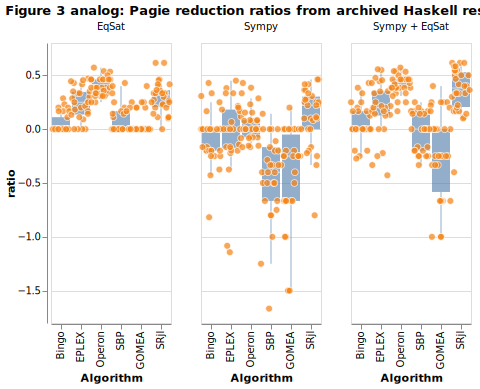

**What this shows:** For the archived Haskell Pagie rows, this is the target paper-era pattern: EqSat is helpful on its own, Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. A faithful Egglog baseline should preserve that separation between the three modes.

In [4]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 3 analog: Pagie reduction ratios from archived Haskell results",
    )
)
show_note(
    summarize_haskell_reduction_ratios(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        context="the archived Haskell Pagie rows",
    )
)

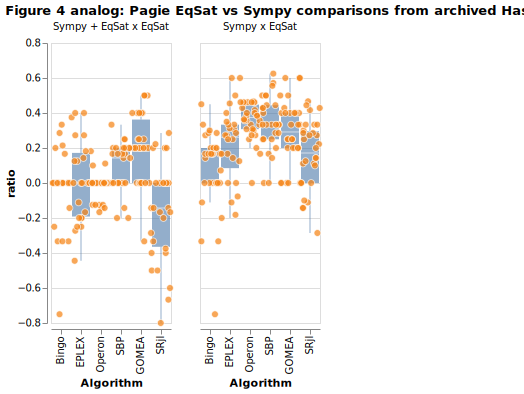

**What this shows:** For the archived Haskell Pagie comparisons, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage.

In [5]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 4 analog: Pagie EqSat vs Sympy comparisons from archived Haskell results",
    )
)
show_note(
    summarize_haskell_comparison_ratios(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        context="the archived Haskell Pagie comparisons",
    )
)

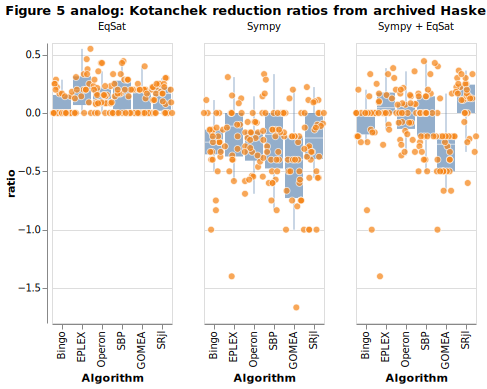

**What this shows:** For the archived Haskell Kotanchek rows, this is the target paper-era pattern: EqSat is helpful on its own, Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. A faithful Egglog baseline should preserve that separation between the three modes.

In [6]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 5 analog: Kotanchek reduction ratios from archived Haskell results",
    )
)
show_note(
    summarize_haskell_reduction_ratios(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        context="the archived Haskell Kotanchek rows",
    )
)

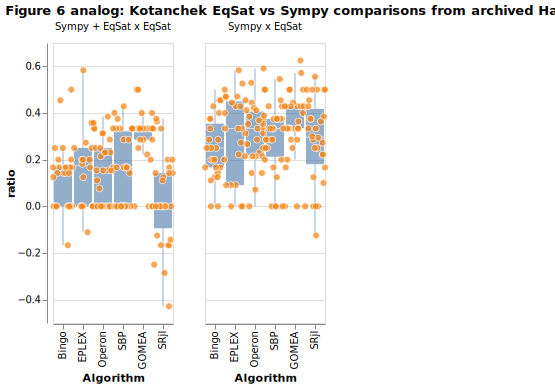

**What this shows:** For the archived Haskell Kotanchek comparisons, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage.

In [7]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 6 analog: Kotanchek EqSat vs Sympy comparisons from archived Haskell results",
    )
)
show_note(
    summarize_haskell_comparison_ratios(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        context="the archived Haskell Kotanchek comparisons",
    )
)

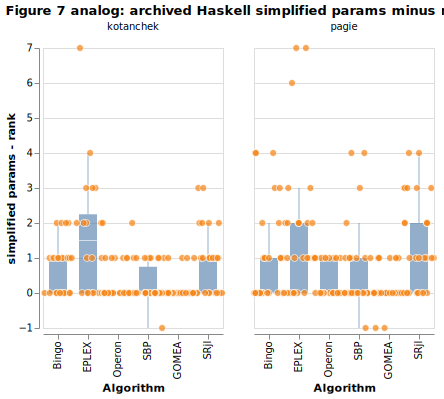

**What this shows:** For the archived Haskell runs, the archived baseline usually lands at or very near the target rank. So the reproduction target here is not just qualitative simplification, but getting most rows down to the rank target or within one.

In [8]:
show_chart(rank_boxplot(haskell, title="Figure 7 analog: archived Haskell simplified params minus rank"))
show_note(summarize_rank_target(haskell, context="the archived Haskell runs"))

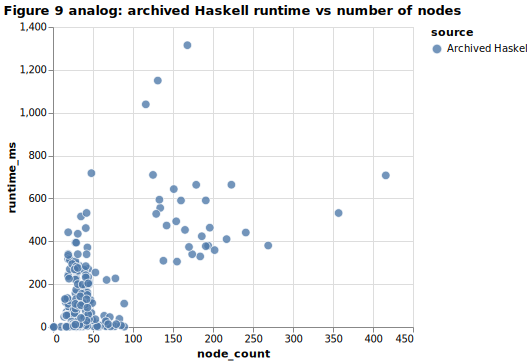

**What this shows:** For the archived Haskell runtime rows, the runtime tail clearly grows with expression size. This is the baseline difficulty pattern Egglog should match qualitatively even if exact runtimes differ.

In [9]:
show_chart(
    runtime_scatter(
        runtime_rows.assign(source="Archived Haskell"),
        x="node_count",
        y="runtime_ms",
        color="source",
        title="Figure 9 analog: archived Haskell runtime vs number of nodes",
    )
)
show_note(
    summarize_runtime_baseline(
        runtime_rows.assign(source="Archived Haskell"),
        x="node_count",
        y="runtime_ms",
        context="the archived Haskell runtime rows",
    )
)

In [10]:
display(Markdown("### Table 4 analog from archived Haskell results"))
display(table4_wide(haskell_table4, ["dataset", "algorithm"]).round(2))

### Table 4 analog from archived Haskell results

,dataset,algorithm,Δ == 0,Δ <= 1
0,kotanchek,Bingo,22.22,66.67
1,kotanchek,EPLEX,18.75,37.50
2,kotanchek,GP-GOMEA,NaN,NaN
3,kotanchek,Operon,74.07,94.44
4,kotanchek,PySR,NaN,NaN
5,kotanchek,SBP,65.22,100.00
6,pagie,Bingo,27.78,33.33
7,pagie,EPLEX,28.00,45.45
8,pagie,GP-GOMEA,NaN,NaN
9,pagie,Operon,66.67,100.00


In [11]:
display(
    Markdown(
        "### Figure 8 status\n\n"
        "The provided archives do not include the bulk Feynman/Operon result table "
        "needed to reproduce Figure 8 exactly, so this notebook marks that figure "
        "as unavailable rather than fabricating an approximation."
    )
)

### Figure 8 status

The provided archives do not include the bulk Feynman/Operon result table needed to reproduce Figure 8 exactly, so this notebook marks that figure as unavailable rather than fabricating an approximation.

## 3. Egglog Translation of the Older Hegg-Era Pipeline

The Egglog runner uses the archived experiment harness as the baseline:
- the older expression language from the paper-era code
- the paper-era extraction cost model
- the `FixTree.hs` rewrite loop and backoff scheduler

In [12]:
baseline_summary = [
    f"- Egglog baseline original-input status counts: `{egglog_baseline['orig_status'].value_counts().to_dict()}`",
    f"- Egglog baseline sympy-input status counts: `{egglog_baseline['sympy_status'].value_counts().to_dict()}`",
]
display(Markdown("## Egglog Run Overview\n\n" + "\n".join(baseline_summary)))

## Egglog Run Overview

- Egglog baseline original-input status counts: `{'saturated': 310, 'timeout': 31}`
- Egglog baseline sympy-input status counts: `{'saturated': 340, 'timeout': 1}`

## 4. Haskell vs Egglog Comparison

The next figures mirror the paper plots with Egglog data. For the Egglog
charts, "Sympy" means the archived Sympy output re-counted by the Egglog
parser, and "Sympy + EqSat" means running the Egglog EqSat translation on the
archived Sympy expression.

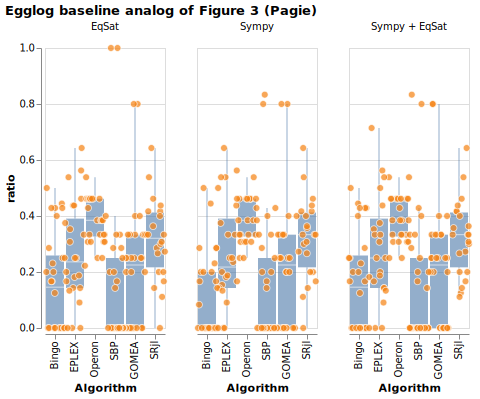

**What this shows:** For the Egglog baseline Pagie rows, Egglog does not preserve the method separation visible in the archived Haskell baseline. The three modes collapse toward the same reduction level, which argues that Egglog is not yet reproducing the distinct effect of each pipeline stage.

In [13]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 3 (Pagie)",
    )
)
show_note(
    summarize_egglog_reduction_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        context="the Egglog baseline Pagie rows",
    )
)

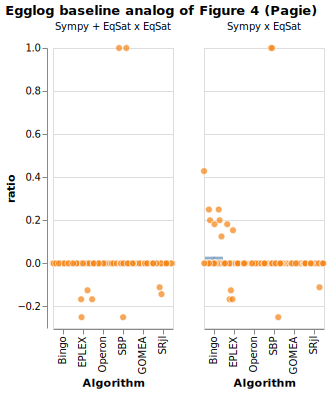

**What this shows:** For the Egglog baseline Pagie comparisons, Egglog largely loses the extra gain that archived Haskell gets from rerunning EqSat after Sympy. That supports the current hypothesis that the remaining gap is in how Egglog reproduces the rewrite schedule and A/C-heavy search, not in the basic parser or metric bookkeeping.

In [14]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 4 (Pagie)",
    )
)
show_note(
    summarize_egglog_comparison_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        context="the Egglog baseline Pagie comparisons",
    )
)

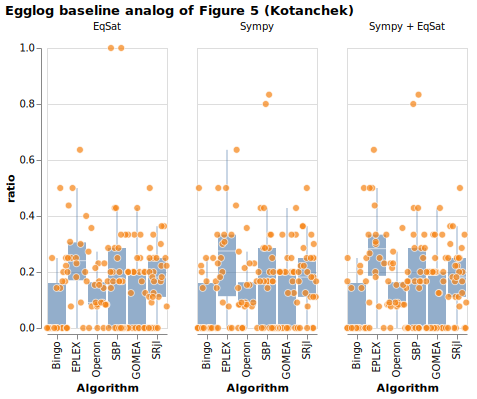

**What this shows:** For the Egglog baseline Kotanchek rows, Egglog does not preserve the method separation visible in the archived Haskell baseline. The three modes collapse toward the same reduction level, which argues that Egglog is not yet reproducing the distinct effect of each pipeline stage.

In [15]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 5 (Kotanchek)",
    )
)
show_note(
    summarize_egglog_reduction_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        context="the Egglog baseline Kotanchek rows",
    )
)

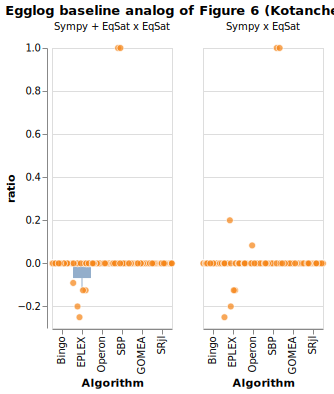

**What this shows:** For the Egglog baseline Kotanchek comparisons, Egglog largely loses the extra gain that archived Haskell gets from rerunning EqSat after Sympy. That supports the current hypothesis that the remaining gap is in how Egglog reproduces the rewrite schedule and A/C-heavy search, not in the basic parser or metric bookkeeping.

In [16]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 6 (Kotanchek)",
    )
)
show_note(
    summarize_egglog_comparison_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        context="the Egglog baseline Kotanchek comparisons",
    )
)

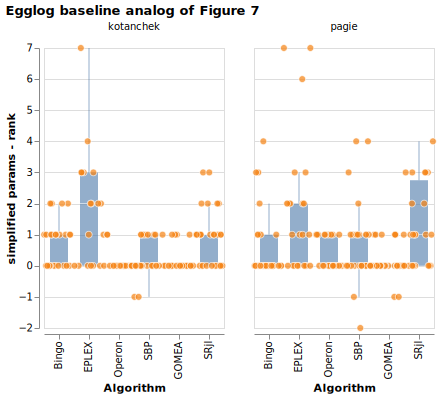

**What this shows:** For the Egglog baseline runs, Egglog is close to the archived baseline on the coarse rank target. So the remaining mismatch is not that Egglog fails to simplify at all; it is that it still misses some of the exact final forms and some hard cases.

In [17]:
show_chart(rank_boxplot(egglog_baseline, title="Egglog baseline analog of Figure 7"))
show_note(summarize_egglog_rank_vs_haskell(egglog_baseline, haskell, context="the Egglog baseline runs"))

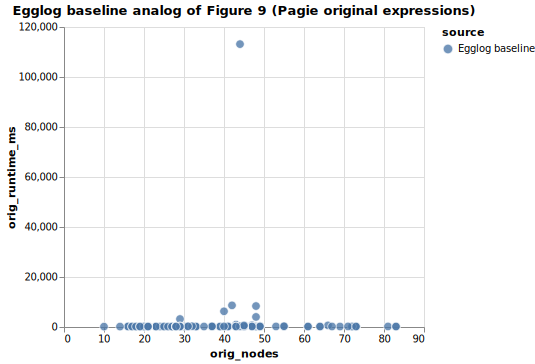

**What this shows:** For the Egglog baseline Pagie originals, runtime does not track size as strongly as in the archived baseline, which would suggest a different failure mode.

In [18]:
show_chart(
    runtime_scatter(
        egglog_baseline[egglog_baseline["dataset"] == "pagie"].assign(source="Egglog baseline"),
        x="orig_nodes",
        y="orig_runtime_ms",
        color="source",
        title="Egglog baseline analog of Figure 9 (Pagie original expressions)",
    )
)
show_note(
    summarize_egglog_runtime(
        egglog_baseline[egglog_baseline["dataset"] == "pagie"].assign(source="Egglog baseline"),
        x="orig_nodes",
        y="orig_runtime_ms",
        context="the Egglog baseline Pagie originals",
    )
)

In [19]:
display(Markdown("### Table 4 analogs for Egglog"))
display(table4_wide(egglog_table4, ["implementation", "dataset", "algorithm"]).round(2))

### Table 4 analogs for Egglog

,implementation,dataset,algorithm,Δ == 0,Δ <= 1
0,Egglog baseline,kotanchek,Bingo,22.22,66.67
1,Egglog baseline,kotanchek,EPLEX,12.50,25.00
2,Egglog baseline,kotanchek,GP-GOMEA,NaN,NaN
3,Egglog baseline,kotanchek,Operon,62.96,61.11
4,Egglog baseline,kotanchek,PySR,NaN,NaN
5,Egglog baseline,kotanchek,SBP,60.87,90.91
6,Egglog baseline,pagie,Bingo,50.00,66.67
7,Egglog baseline,pagie,EPLEX,32.00,40.91
8,Egglog baseline,pagie,GP-GOMEA,NaN,NaN
9,Egglog baseline,pagie,Operon,50.00,80.00


In [20]:
exact_match_rows = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "input": "original expressions",
        "exact_param_matches": int(baseline_compare["orig_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
    {
        "mode": "Egglog baseline",
        "input": "sympy expressions",
        "exact_param_matches": int(baseline_compare["sympy_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
])
display(Markdown("### Exact-match counts against archived Haskell parameter totals"))
display(exact_match_rows)

### Exact-match counts against archived Haskell parameter totals

,mode,input,exact_param_matches,total_rows
0,Egglog baseline,original expressions,286,341
1,Egglog baseline,sympy expressions,125,341


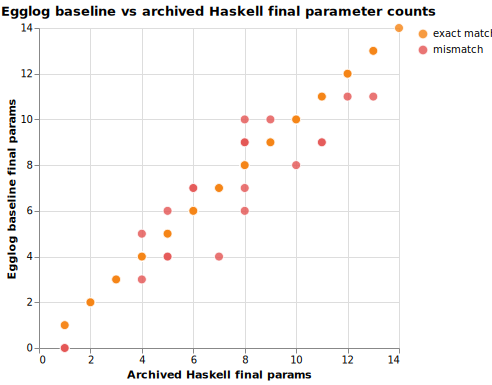

**What this shows:** For saturated original-expression rows, most sit on or very near the diagonal. That supports the hypothesis that Egglog is partially reproducing the Haskell baseline on final parameter counts, but not yet meeting it exactly across the whole corpus.

In [21]:
baseline_orig_scatter = baseline_compare[baseline_compare["orig_status"] == "saturated"].copy()
baseline_orig_scatter["match"] = baseline_orig_scatter["orig_param_match"].map({True: "exact match", False: "mismatch"})
show_chart(
    alt.Chart(baseline_orig_scatter)
    .mark_circle(size=78, opacity=0.82, stroke="white", strokeWidth=0.85)
    .encode(
        x=alt.X("simpl_params_haskell:Q", title="Archived Haskell final params"),
        y=alt.Y("simpl_params_egglog:Q", title="Egglog baseline final params"),
        color=alt.Color(
            "match:N",
            title=None,
            scale=alt.Scale(domain=["exact match", "mismatch"], range=[POINT_COLOR, MISMATCH_COLOR]),
        ),
        tooltip=["dataset", "algorithm", "algo_row", "simpl_params_haskell", "simpl_params_egglog", "orig_rendered"],
    )
    .properties(title="Egglog baseline vs archived Haskell final parameter counts", width=360, height=320)
)
show_note(summarize_match_scatter(baseline_orig_scatter, context="saturated original-expression rows"))

In [22]:
baseline_summary_frame = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "orig_non_saturated_rows": int((egglog_baseline["orig_status"] != "saturated").sum()),
        "sympy_non_saturated_rows": int((egglog_baseline["sympy_status"] != "saturated").sum()),
        "median_orig_runtime_ms": float(egglog_baseline["orig_runtime_ms"].median()),
        "median_sympy_runtime_ms": float(egglog_baseline["sympy_runtime_ms"].median()),
    },
])
display(Markdown("### Egglog baseline summary"))
display(baseline_summary_frame.round(2))

### Egglog baseline summary

,mode,orig_non_saturated_rows,sympy_non_saturated_rows,median_orig_runtime_ms,median_sympy_runtime_ms
0,Egglog baseline,31,1,196.97,177.62


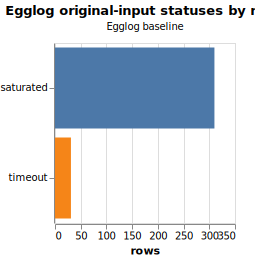

**What this shows:** For Egglog original-input runs, most finish in the normal saturated path. That means the current baseline is usable for comparison work, but the remaining unsaturated tail is still large enough to matter for paper-faithful reproduction.

In [23]:
show_chart(
    status_summary_chart(
        status_rows.groupby(["mode", "status"]).size().reset_index(name="count"),
        title="Egglog original-input statuses by mode",
    )
)
show_note(
    summarize_status_counts(
        status_rows.groupby(["mode", "status"]).size().reset_index(name="count"),
        context="Egglog original-input runs",
    )
)

In [24]:
display(
    Markdown(
        "\n".join([
            "## Comparison Summary",
            "",
            f"- Egglog baseline exactly matches archived Haskell final parameter counts on `{int(baseline_compare['orig_param_match'].sum())}` of `{len(baseline_compare)}` original-expression rows.",
            f"- Egglog baseline exactly matches archived Haskell `Sympy + EqSat` parameter counts on `{int(baseline_compare['sympy_param_match'].sum())}` of `{len(baseline_compare)}` sympy-expression rows.",
            f"- Egglog baseline original-input timeouts or failures occur on `{int((egglog_baseline['orig_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
            f"- Egglog baseline sympy-input timeouts or failures occur on `{int((egglog_baseline['sympy_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
        ])
    )
)

## Comparison Summary

- Egglog baseline exactly matches archived Haskell final parameter counts on `286` of `341` original-expression rows.
- Egglog baseline exactly matches archived Haskell `Sympy + EqSat` parameter counts on `125` of `341` sympy-expression rows.
- Egglog baseline original-input timeouts or failures occur on `31` of `341` paper rows.
- Egglog baseline sympy-input timeouts or failures occur on `1` of `341` paper rows.

## 5. Current Limitations and Likely A/C Effects

The statements below are derived from the loaded artifacts and then connected
back to the rewrite structure in the archived source.

In [25]:
baseline_failures = egglog_baseline[egglog_baseline["orig_status"] != "saturated"].copy()
failure_by_algorithm = baseline_failures.groupby("algorithm").size().sort_values(ascending=False)
sympy_success_delta = int(
    (egglog_baseline["sympy_status"] == "saturated").sum() - (egglog_baseline["orig_status"] == "saturated").sum()
)
source_node_sizes = haskell[["dataset", "raw_index", "algorithm", "orig_nodes"]].rename(
    columns={"orig_nodes": "source_orig_nodes"}
)
baseline_failures_with_sizes = baseline_failures.merge(
    source_node_sizes, on=["dataset", "raw_index", "algorithm"], how="left"
)
baseline_sat_with_sizes = egglog_baseline[egglog_baseline["orig_status"] == "saturated"].merge(
    source_node_sizes,
    on=["dataset", "raw_index", "algorithm"],
    how="left",
)
baseline_timeout_median_nodes = baseline_failures_with_sizes["source_orig_nodes"].median()
baseline_sat_median_nodes = baseline_sat_with_sizes["source_orig_nodes"].median()

conclusion_lines = [
    f"- The Egglog baseline saturates on `{int((egglog_baseline['orig_status'] == 'saturated').sum())}` of `{len(egglog_baseline)}` original paper rows, but on `{int((egglog_baseline['sympy_status'] == 'saturated').sum())}` of `{len(egglog_baseline)}` archived Sympy rows.",
    f"- The archived Sympy inputs therefore remove `{sympy_success_delta}` baseline failures, which is consistent with the paper's observation that preprocessing can cut down the parameter-reduction problem before EqSat runs.",
    f"- Using the archived source-node counts for the same rows, the median original node count for Egglog baseline failures is `{baseline_timeout_median_nodes:.1f}`, versus `{baseline_sat_median_nodes:.1f}` for saturated rows; the runtime tail still tracks expression size.",
    f"- Failures are concentrated in `{', '.join(f'{alg} ({count})' for alg, count in failure_by_algorithm.items()) or 'none'}`, which points to specific expression families rather than a uniform issue across all algorithms.",
    f"- The baseline still has a median original-input gap-to-rank of `{float(egglog_baseline['simpl_rank'].median()):.2f}`, versus `{float(haskell['simpl_rank'].median()):.2f}` in the archived Haskell results.",
    "",
    "The archived rule sets suggest that A/C pressure is most likely to affect:",
    "- `+` and `*` associativity and commutativity rewrites, especially when chained through factorization-style rewrites and reciprocal rewrites.",
    "- distributivity and refactorization rules that depend on binary tree shape, such as `(x*y) + (x*z) -> x*(y+z)` and its surrounding normalization rules.",
    "- power-merging and logarithm rewrites, where repeated multiplication and reassociation can create many equivalent binary trees before extraction.",
    "",
    "The best follow-up points for a multiset experiment are:",
    "- additive islands that currently rely on repeated binary reassociation before a factorization rewrite becomes visible",
    "- multiplicative islands that feed reciprocal and logarithm rewrites",
    "- classes where constant-analysis guards still block paper rewrites that the Haskell implementation can fire after rebuild",
    "",
    "The expected outcomes to test next are:",
    "- a shorter runtime tail on the Pagie expressions that currently timeout in Egglog baseline",
    "- fewer rows where Egglog remains above the archived rank target after simplification",
    "- less dependence on repeated binary reassociation once A/C-heavy structure is containerized directly",
]
display(Markdown("## Conclusion\n\n" + "\n".join(conclusion_lines)))

## Conclusion

- The Egglog baseline saturates on `310` of `341` original paper rows, but on `340` of `341` archived Sympy rows.
- The archived Sympy inputs therefore remove `30` baseline failures, which is consistent with the paper's observation that preprocessing can cut down the parameter-reduction problem before EqSat runs.
- Using the archived source-node counts for the same rows, the median original node count for Egglog baseline failures is `45.0`, versus `30.0` for saturated rows; the runtime tail still tracks expression size.
- Failures are concentrated in `Operon (14), SRjl (9), EPLEX (4), Bingo (2), GOMEA (1), SBP (1)`, which points to specific expression families rather than a uniform issue across all algorithms.
- The baseline still has a median original-input gap-to-rank of `0.00`, versus `0.00` in the archived Haskell results.

The archived rule sets suggest that A/C pressure is most likely to affect:
- `+` and `*` associativity and commutativity rewrites, especially when chained through factorization-style rewrites and reciprocal rewrites.
- distributivity and refactorization rules that depend on binary tree shape, such as `(x*y) + (x*z) -> x*(y+z)` and its surrounding normalization rules.
- power-merging and logarithm rewrites, where repeated multiplication and reassociation can create many equivalent binary trees before extraction.

The best follow-up points for a multiset experiment are:
- additive islands that currently rely on repeated binary reassociation before a factorization rewrite becomes visible
- multiplicative islands that feed reciprocal and logarithm rewrites
- classes where constant-analysis guards still block paper rewrites that the Haskell implementation can fire after rebuild

The expected outcomes to test next are:
- a shorter runtime tail on the Pagie expressions that currently timeout in Egglog baseline
- fewer rows where Egglog remains above the archived rank target after simplification
- less dependence on repeated binary reassociation once A/C-heavy structure is containerized directly

In [26]:
def _write_executed_notebook() -> None:
    source_path = PARAM_EQ_DIR / "replication.py"
    output_path = source_path.with_suffix(".ipynb")
    notebook = jupytext.read(source_path, fmt="py:light")
    previous = os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB")
    os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = "0"
    try:
        executed = NotebookClient(notebook, timeout=600, kernel_name="python3").execute()
    finally:
        if previous is None:
            os.environ.pop("EGGLOG_PARAM_EQ_SYNC_IPYNB", None)
        else:
            os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = previous
    with output_path.open("w", encoding="utf-8") as handle:
        nbformat.write(executed, handle)

In [27]:
if __name__ == "__main__" and os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB", "1") != "0":
    _write_executed_notebook()